In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    StandardScaler,
    MinMaxScaler,
    RobustScaler
)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully!")

Libraries imported successfully!


In [8]:
df = pd.read_csv("../Outputs/pipeline1_clean.csv")
print("Dataset loaded successfully!")

print(f"Dataset Shape: {df.shape}")
print(f"Total Missing Values: {df.isnull().sum().sum()}")

df.head()

Dataset loaded successfully!
Dataset Shape: (1460, 77)
Total Missing Values: 2422


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,0,12,2008,WD,Normal,250000


In [9]:
# ==========================================================
# Summary
# In this step, I separated the target variable (SalePrice)
# from the feature set. I also removed the Id column because
# it is only an identifier and does not provide useful
# information for model training.
# ==========================================================

# Separate target variable
y = df["SalePrice"].copy()

# Separate features
X = df.drop("SalePrice", axis=1)

# Remove Id column (not useful for modeling)
if "Id" in X.columns:
    X = X.drop("Id", axis=1)

# Print dataset information
print(f"Features Shape : {X.shape}")
print(f"Target Shape   : {y.shape}")

print("\nTarget Statistics:")
print(y.describe())

Features Shape : (1460, 75)
Target Shape   : (1460,)

Target Statistics:
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


In [ ]:

# Identify feature types
categorical_features = X.select_dtypes(include=["object", "string"]).columns.tolist()
numerical_features = X.select_dtypes(include=["number"]).columns.tolist()

# ==========================================================
# Summary
# In this step, I categorized categorical features into
# ordinal and nominal groups based on the official
# data_description.txt. This separation ensures that the
# correct encoding technique is applied in the next step.
# ==========================================================

# ==========================================================
# Ordinal Feature Mappings
# ==========================================================

ordinal_mappings = {

    # Quality Features
    "ExterQual": {"Po":1, "Fa":2, "TA":3, "Gd":4, "Ex":5},
    "ExterCond": {"Po":1, "Fa":2, "TA":3, "Gd":4, "Ex":5},
    "HeatingQC": {"Po":1, "Fa":2, "TA":3, "Gd":4, "Ex":5},
    "KitchenQual": {"Po":1, "Fa":2, "TA":3, "Gd":4, "Ex":5},
    "GarageQual": {"NA":0, "Po":1, "Fa":2, "TA":3, "Gd":4, "Ex":5},
    "GarageCond": {"NA":0, "Po":1, "Fa":2, "TA":3, "Gd":4, "Ex":5},
    "FireplaceQu": {"NA":0, "Po":1, "Fa":2, "TA":3, "Gd":4, "Ex":5},
    "PoolQC": {"NA":0, "Fa":2, "TA":3, "Gd":4, "Ex":5},

    # Basement
    "BsmtQual": {"NA":0, "Po":1, "Fa":2, "TA":3, "Gd":4, "Ex":5},
    "BsmtCond": {"NA":0, "Po":1, "Fa":2, "TA":3, "Gd":4, "Ex":5},
    "BsmtExposure": {"NA":0, "No":1, "Mn":2, "Av":3, "Gd":4},
    "BsmtFinType1": {"NA":0, "Unf":1, "LwQ":2, "Rec":3, "BLQ":4, "ALQ":5, "GLQ":6},
    "BsmtFinType2": {"NA":0, "Unf":1, "LwQ":2, "Rec":3, "BLQ":4, "ALQ":5, "GLQ":6},

    # Garage
    "GarageFinish": {"NA":0, "Unf":1, "RFn":2, "Fin":3},

    # Functional
    "Functional": {
        "Sal":1,
        "Sev":2,
        "Maj2":3,
        "Maj1":4,
        "Mod":5,
        "Min2":6,
        "Min1":7,
        "Typ":8
    },

    # Lot
    "LotShape": {
        "IR3":1,
        "IR2":2,
        "IR1":3,
        "Reg":4
    },

    "LandSlope": {
        "Sev":1,
        "Mod":2,
        "Gtl":3
    },

    # Utilities
    "Utilities": {
        "ELO":1,
        "NoSeWa":2,
        "NoSewr":3,
        "AllPub":4
    },

    # Paved Drive
    "PavedDrive": {
        "N":0,
        "P":1,
        "Y":2
    },

    # Fence
    "Fence": {
        "NA":0,
        "MnWw":1,
        "GdWo":2,
        "MnPrv":3,
        "GdPrv":4
    }
}

# ==========================================================
# Separate Ordinal and Nominal Features
# ==========================================================


ordinal_features = [
    col for col in ordinal_mappings.keys()
    if col in X.columns
]

nominal_features = [
    col for col in categorical_features
    if col not in ordinal_features
]



# ==========================================================
# Display Results
# ==========================================================

print(f"Number of Ordinal Features : {len(ordinal_features)}")
print(f"Number of Nominal Features : {len(nominal_features)}")

print("\nOrdinal Features")
print(ordinal_features)

print("\nNominal Features")
print(nominal_features)



Number of Ordinal Features : 20
Number of Nominal Features : 21

Ordinal Features
['ExterQual', 'ExterCond', 'HeatingQC', 'KitchenQual', 'GarageQual', 'GarageCond', 'FireplaceQu', 'PoolQC', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'GarageFinish', 'Functional', 'LotShape', 'LandSlope', 'Utilities', 'PavedDrive', 'Fence']

Nominal Features
['MSZoning', 'Street', 'LandContour', 'LotConfig', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'Heating', 'CentralAir', 'Electrical', 'GarageType', 'SaleType', 'SaleCondition']


In [ ]:
print(len(categorical_features))
print(len(ordinal_features)+len(nominal_features))

39
39


In [15]:
ordinal_features = [
    col for col in ordinal_mappings.keys()
    if col in X.columns
]

nominal_features = [
    col for col in categorical_features
    if col not in ordinal_features
]

In [21]:
# ==========================================================
# Summary
# In this step, I applied One-Hot Encoding to all nominal
# categorical features. This converts categorical values
# into binary columns so that machine learning models can
# process them correctly.
# ==========================================================

# ==========================================================
# Apply One-Hot Encoding
# ==========================================================


X_encoded = X.copy()

for feature, mapping in ordinal_mappings.items():

    if feature in X_encoded.columns:
        X_encoded[feature] = X_encoded[feature].replace(mapping)

print("\nOrdinal Encoding completed successfully!")

# ==========================================================
# Apply One-Hot Encoding
# ==========================================================

X_encoded = pd.get_dummies(
    X_encoded,
    columns=nominal_features,
    drop_first=True
)

print("One-Hot Encoding completed successfully!")

# ==========================================================
# Final Information
# ==========================================================

print(f"\nFinal Dataset Shape : {X_encoded.shape}")
print(f"Total Features      : {X_encoded.shape[1]}")

print("\nFirst 5 rows:")
display(X_encoded.head())


Ordinal Encoding completed successfully!
One-Hot Encoding completed successfully!

Final Dataset Shape : (1460, 192)
Total Features      : 192

First 5 rows:


,MSSubClass,LotFrontage,LotArea,LotShape,Utilities,LandSlope,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,ExterCond,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,HeatingQC,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Pave,LandContour_HLS,LandContour_Low,LandContour_Lvl,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Condition1_Feedr,Condition1_Norm,Condition1_PosA,Condition1_PosN,Condition1_RRAe,Condition1_RRAn,Condition1_RRNe,Condition1_RRNn,Condition2_Feedr,Condition2_Norm,Condition2_PosA,Condition2_PosN,Condition2_RRAe,Condition2_RRAn,Condition2_RRNn,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,RoofStyle_Gable,RoofStyle_Gambrel,RoofStyle_Hip,RoofStyle_Mansard,RoofStyle_Shed,RoofMatl_CompShg,RoofMatl_Membran,RoofMatl_Metal,RoofMatl_Roll,RoofMatl_Tar&Grv,RoofMatl_WdShake,RoofMatl_WdShngl,Exterior1st_AsphShn,Exterior1st_BrkComm,Exterior1st_BrkFace,Exterior1st_CBlock,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing,Exterior2nd_AsphShn,Exterior2nd_Brk Cmn,Exterior2nd_BrkFace,Exterior2nd_CBlock,Exterior2nd_CmentBd,Exterior2nd_HdBoard,Exterior2nd_ImStucc,Exterior2nd_MetalSd,Exterior2nd_Other,Exterior2nd_Plywood,Exterior2nd_Stone,Exterior2nd_Stucco,Exterior2nd_VinylSd,Exterior2nd_Wd Sdng,Exterior2nd_Wd Shng,MasVnrType_BrkFace,MasVnrType_Stone,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,Heating_GasA,Heating_GasW,Heating_Grav,Heating_OthW,Heating_Wall,CentralAir_Y,Electrical_FuseF,Electrical_FuseP,Electrical_Mix,Electrical_SBrkr,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,60,65.0,8450,4,4,3,7,5,2003,2003,196.0,4,3,4,3,1,6,706,1,0,150,856,5,856,854,0,1710,1,0,2,1,3,1,4,8,8,0,NaN,2003.0,2,2,548,3,3,2,0,61,0,0,0,0,0,2,2008,False,False,True,False,True,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False
1,20,80.0,9600,4

In [ ]:
# ==========================================================
# Summary
# In this step, I analyzed the distribution of numerical
# features by calculating their skewness. The goal is to
# identify highly skewed variables that may benefit from
# logarithmic transformation in the next preprocessing step.
# ==========================================================


In [23]:
# ==========================================================
# Calculate Skewness
# ==========================================================

numeric_columns = X_encoded.select_dtypes(include=["number"]).columns

skewness_df = pd.DataFrame({
    "Feature": numeric_columns,
    "Skewness": [
        stats.skew(X_encoded[col].dropna())
        for col in numeric_columns
    ]
})

skewness_df["Abs_Skewness"] = skewness_df["Skewness"].abs()

skewness_df = skewness_df.sort_values(
    by="Abs_Skewness",
    ascending=False
).reset_index(drop=True)

print("Top 20 Most Skewed Features:\n")
display(skewness_df.head(20))



# ==========================================================
# Highly Skewed Features
# ==========================================================

highly_skewed = skewness_df[
    skewness_df["Abs_Skewness"] > 0.75
]["Feature"].tolist()

print(f"Number of Highly Skewed Features : {len(highly_skewed)}")

print("\nHighly Skewed Features:\n")
print(highly_skewed)



Top 20 Most Skewed Features:



,Feature,Skewness,Abs_Skewness
0,MiscVal,24.451640,24.451640
1,PoolArea,14.813135,14.813135
2,LotArea,12.195142,12.195142
3,3SsnPorch,10.293752,10.293752
4,LowQualFinSF,9.002080,9.002080
5,KitchenAbvGr,4.483784,4.483784
6,BsmtFinSF2,4.250888,4.250888
7,ScreenPorch,4.117977,4.117977
8,BsmtHalfBath,4.099186,4.099186
9,EnclosedPorch,3.086696,3.086696


Number of Highly Skewed Features : 21

Highly Skewed Features:

['MiscVal', 'PoolArea', 'LotArea', '3SsnPorch', 'LowQualFinSF', 'KitchenAbvGr', 'BsmtFinSF2', 'ScreenPorch', 'BsmtHalfBath', 'EnclosedPorch', 'MasVnrArea', 'OpenPorchSF', 'LotFrontage', 'BsmtFinSF1', 'WoodDeckSF', 'TotalBsmtSF', 'MSSubClass', '1stFlrSF', 'GrLivArea', 'BsmtUnfSF', '2ndFlrSF']


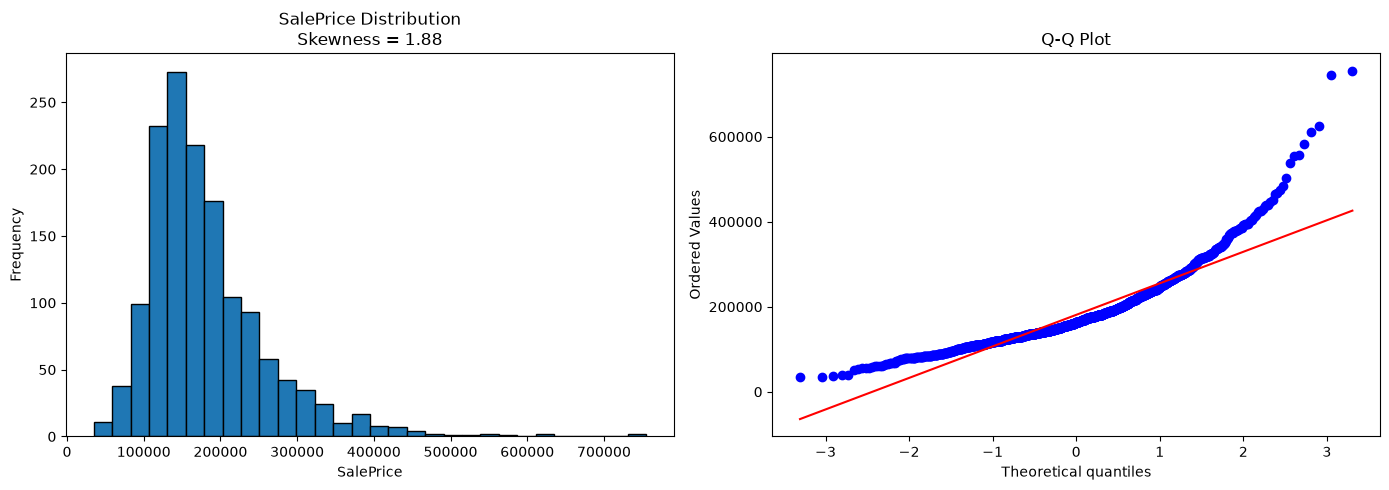

SalePrice Skewness : 1.881


In [24]:
# ==========================================================
# Target Distribution
# ==========================================================

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Histogram
axes[0].hist(
    y,
    bins=30,
    edgecolor="black"
)

axes[0].set_title(
    f"SalePrice Distribution\nSkewness = {stats.skew(y):.2f}"
)

axes[0].set_xlabel("SalePrice")
axes[0].set_ylabel("Frequency")

# QQ Plot
stats.probplot(y, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot")

plt.tight_layout()
plt.show()

print(f"SalePrice Skewness : {stats.skew(y):.3f}")